# 1. Load dan standarisasi dataset

### a. Data Preprocessing

In [81]:
# Import Library Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [82]:
# Load dataset
breast_cancer_wisconsin = load_breast_cancer()
X = pd.DataFrame(breast_cancer_wisconsin.data, columns=breast_cancer_wisconsin.feature_names)
y = breast_cancer_wisconsin.target

df_breast_cancer_wisconsin = pd.DataFrame(breast_cancer_wisconsin.data, columns=breast_cancer_wisconsin.feature_names) # Variabel X
df_breast_cancer_wisconsin['target'] = breast_cancer_wisconsin.target # Variabel Y
df_breast_cancer_wisconsin.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [83]:
# Overview Dataset
print(f"Jumlah observasi: {df_breast_cancer_wisconsin.shape[0]}")
print(f"Jumlah variabel fitur: {df_breast_cancer_wisconsin.shape[1]}")
print(f"Jumlah missing value:\n{X.isnull().sum().sum()}")

Jumlah observasi: 569
Jumlah variabel fitur: 31
Jumlah missing value:
0


### b. Standarisasi Data

In [84]:
# Lakukan Standarisasi Dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


# 2. Principal Component Analysis (PCA)

### a. Analisis PCA dan Visualisasi Screeplot

In [85]:
# Lakukan Analisis PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

pca_table = pd.DataFrame({
    "PC": range(1, 31),
    "Explained Variance": exp_var,
    "Cumulative Variance": cum_var
})
display(pca_table)

,PC,Explained Variance,Cumulative Variance
0,1,0.442720,0.442720
1,2,0.189712,0.632432
2,3,0.093932,0.726364
3,4,0.066021,0.792385
4,5,0.054958,0.847343
5,6,0.040245,0.887588
6,7,0.022507,0.910095
7,8,0.015887,0.925983
8,9,0.013896,0.939879
9,10,0.011690,0.951569


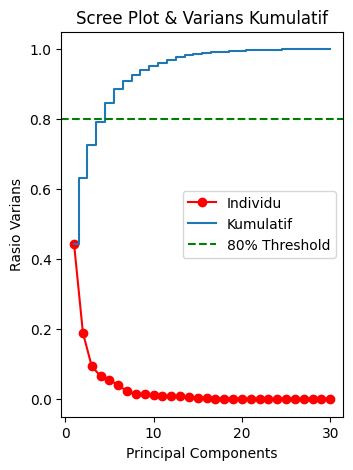

In [86]:
# Visualisasi Screeplot
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(exp_var) + 1), exp_var, 'ro-', label='Individu')
plt.step(range(1, len(cum_var) + 1), cum_var, where='mid', label='Kumulatif')
plt.axhline(y=0.80, color='g', linestyle='--', label='80% Threshold')
plt.title('Scree Plot & Varians Kumulatif')
plt.xlabel('Principal Components')
plt.ylabel('Rasio Varians')
plt.legend()

In [87]:
# Lakukan Analisis PCA reduksi 2 komponen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Hitung Varians Eksplanasi dan Total Varians Kumulatif
print(f"Varians PC1: {exp_var[0]:.4f}, PC2: {exp_var[1]:.4f}")
print(f"Total Varians Kumulatif (2 PC): {cum_var[1]:.4f}")

Varians PC1: 0.4427, PC2: 0.1897
Total Varians Kumulatif (2 PC): 0.6324


### b. Tentukan loadings dan visualisasi PC1 dan PC2

In [88]:
# Loadings PC1 dan PC2
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns)

# Cari 3 Kontributor Utama dari PC1 dan PC2
print("\nTop 3 Kontributor Positif Terbesar PC1:")
print(loadings['PC1'].sort_values(ascending=False).head(3))
print("\nTop 3 Kontributor Positif Terbesar PC2:")
print(loadings['PC2'].sort_values(ascending=False).head(3))


Top 3 Kontributor Positif Terbesar PC1:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
Name: PC1, dtype: float64

Top 3 Kontributor Positif Terbesar PC2:
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
Name: PC2, dtype: float64


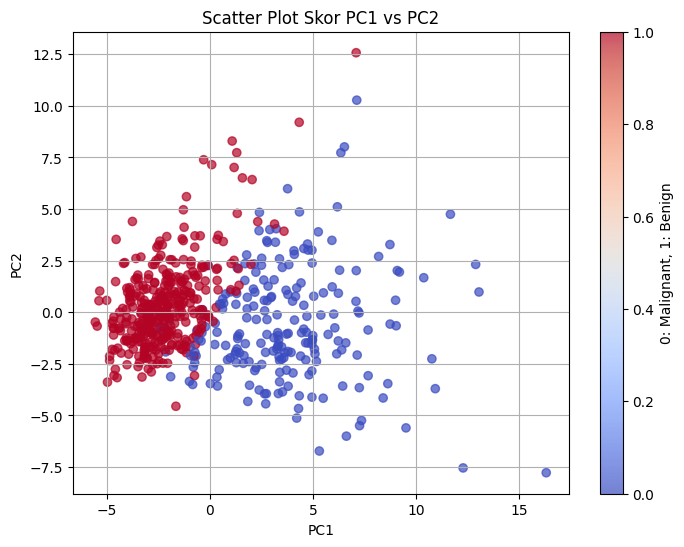

In [89]:
# Visualisasi Skor PC1 & PC2
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap = 'coolwarm', alpha = 0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatter Plot Skor PC1 vs PC2')
plt.colorbar(scatter, label='0: Malignant, 1: Benign')
plt.grid()
plt.show()

# 3. Factor Analysis

In [94]:
# Lakukan Analisis Faktor dengan k = 4 berdasarkan Visualisasi Screeplot
fa = FactorAnalysis(n_components = 4, random_state=42)
X_fa = fa.fit_transform(X_scaled)
fa_loadings = pd.DataFrame(fa.components_.T, columns=[f'Factor{i+1}' for i in range(4)], index=X.columns)

# Tampilkan Loadings Faktor 1 dan Faktor 2
print("\n--- Faktor Loadings Faktor 1 dan Faktor 2 ---")
print(fa_loadings[['Factor1', 'Factor2']])

print("\n--- Faktor Loadings Faktor 3 dan Faktor 4 ---")
print(fa_loadings[['Factor3', 'Factor4']])


--- Faktor Loadings Faktor 1 dan Faktor 2 ---
                          Factor1   Factor2
mean radius              0.999732 -0.014447
mean texture             0.336187  0.849152
mean perimeter           0.998594 -0.006454
mean area                0.987870 -0.020448
mean smoothness          0.179101 -0.007009
mean compactness         0.518499  0.109635
mean concavity           0.687297  0.105243
mean concave points      0.830026  0.047213
mean symmetry            0.156826  0.057244
mean fractal dimension  -0.299647  0.062375
radius error             0.685772 -0.015101
texture error           -0.087800  0.458236
perimeter error          0.681918 -0.006758
area error               0.741159 -0.033244
smoothness error        -0.216649 -0.001341
compactness error        0.217306  0.096186
concavity error          0.203005  0.053099
concave points error     0.383770 -0.021604
symmetry error          -0.098608 -0.041974
fractal dimension error -0.033518  0.022237
worst radius             0.97

# 4. Clustering Analysis

### a. Penentuan Jumlah Klaster

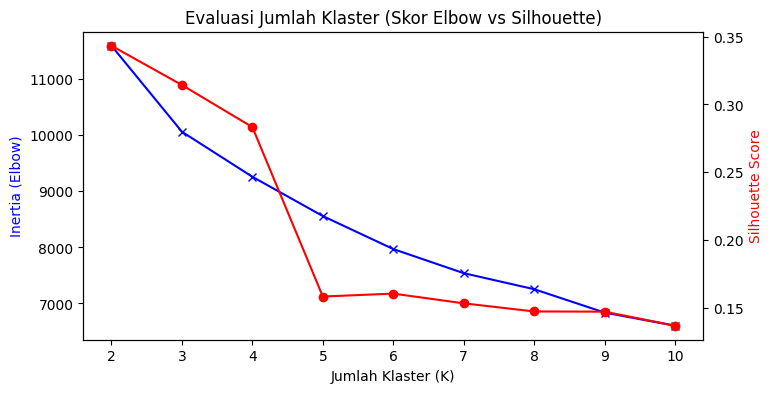

In [101]:
# Penentuan Jumlah Klaster Terbaik (Elbow dan Silhouette)
inertia = []
silhouette_vals = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow dan Silhouette
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(K_range, inertia, 'bx-')
ax1.set_xlabel('Jumlah Klaster (K)')
ax1.set_ylabel('Inertia (Elbow)', color='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_vals, 'ro-')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Evaluasi Jumlah Klaster (Skor Elbow vs Silhouette)')
plt.show()

### b. Profiling Cluster K = 2

Jumlah Anggota tiap Cluster:
Cluster
0    375
1    194
Name: count, dtype: int64

Profil Rata-Rata Geometri Utama Per Cluster:
         mean radius  mean texture   mean area
Cluster                                       
0          12.426691     18.262427  486.772267
1          17.414536     21.275258  979.857216


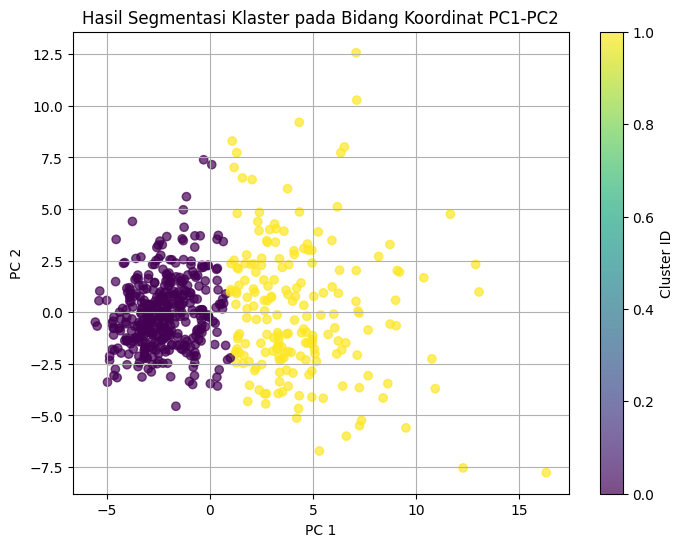

In [100]:
# Lakukan profiling klaster dengan K=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans_final.fit_transform(X_scaled)
X['Cluster'] = kmeans_final.labels_

# Jumlah anggota tiap cluster
print("Jumlah Anggota tiap Klaster:")
print(X['Cluster'].value_counts())

# Profiling singkat rerata variabel geometri utama
print("\nProfil Rata-Rata Geometri Utama Per Cluster:")
print(X.groupby('Cluster')[['mean radius', 'mean texture', 'mean area']].mean())

# Visualisasi Klaster di Ruang PC1 dan PC2
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_final.labels_, cmap='viridis', alpha=0.7)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Hasil Segmentasi Klaster pada Bidang Koordinat PC1-PC2')
plt.colorbar(label='Cluster ID')
plt.grid(True)
plt.show()